Model Slope (Signal): 0.047
Mean Absolute Error: 1.183
Accuracy Score (R^2): 0.874


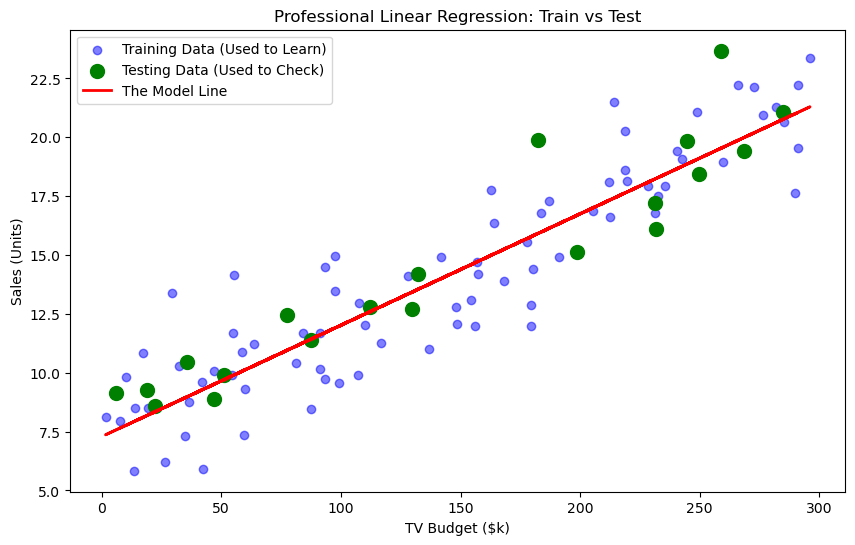

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. THE DATA (Simulating a larger professional dataset)
# Imagine this is 100 months of data
np.random.seed(42)
tv_budget = np.random.rand(100, 1) * 300  # Budget between 0 and 300k
# Sales = 0.05 * Budget + 7 + Noise
sales = 0.05 * tv_budget + 7 + np.random.randn(100, 1) * 2

# 2. THE SPLIT (The "Professional" Standard)
# We hide 20% of the data to test the model later
X_train, X_test, y_train, y_test = train_test_split(tv_budget, sales, test_size=0.2, random_state=42)

# 3. TRAINING (Learning the Signal)
# We ONLY show the model the training data
model = LinearRegression()
model.fit(X_train, y_train)

# 4. PREDICTION & EVALUATION (The "Accuracy Check")
# We ask the model to predict the 'Test' data it has never seen
predictions = model.predict(X_test)

# Calculate "Mean Absolute Error" (Average distance between prediction and reality)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Slope (Signal): {model.coef_[0][0]:.3f}")
print(f"Mean Absolute Error: {mae:.3f}")
print(f"Accuracy Score (R^2): {r2:.3f}")

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data (Used to Learn)')
plt.scatter(X_test, y_test, color='green', s=100, label='Testing Data (Used to Check)')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='The Model Line')

plt.title('Professional Linear Regression: Train vs Test')
plt.xlabel('TV Budget ($k)')
plt.ylabel('Sales (Units)')
plt.legend()
plt.show()
